In [3]:
%pip install pandas numpy matplotlib pyfixest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 46.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 22.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 43.1 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 95.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 28.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 31.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 48.7 MB/s  0:00:01m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 95.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27/27 [pyfixest]/27 [pyfixest]les]adata]]
Note: you may need to restart the kernel to use updated packag

# Imports

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pyfixest as pf
 

import os

folder_path = "./output/simulations_uncertainty_fixed_cost"

# Tests


## Test 1 

- No uncertainty
- Same fixed cost for begining and mid year

Increasing both fixed cost should increase the size of the SS band. 

In [2]:
test = 1

<Axes: xlabel='year'>

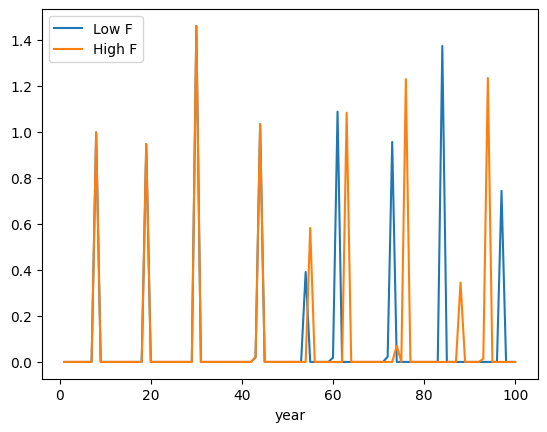

In [20]:
panel_1 = pd.read_parquet(os.path.join(folder_path,f"panel_data_s{test}1.parquet"))
panel_2 = pd.read_parquet(os.path.join(folder_path,f"panel_data_s{test}2.parquet"))

fix, ax = plt.subplots()
panel_1.query('firm_id == 1').plot(x = "year",y = 'I_total',ax =ax,label = "Low F")
panel_2.query('firm_id == 1').plot(x = "year",y = 'I_total',ax =ax,label = "High F")

In [34]:
os.listdir("output")

['simulations_no_uncertainty_fixed_cost', 'simulations_uncertainty_fixed_cost']

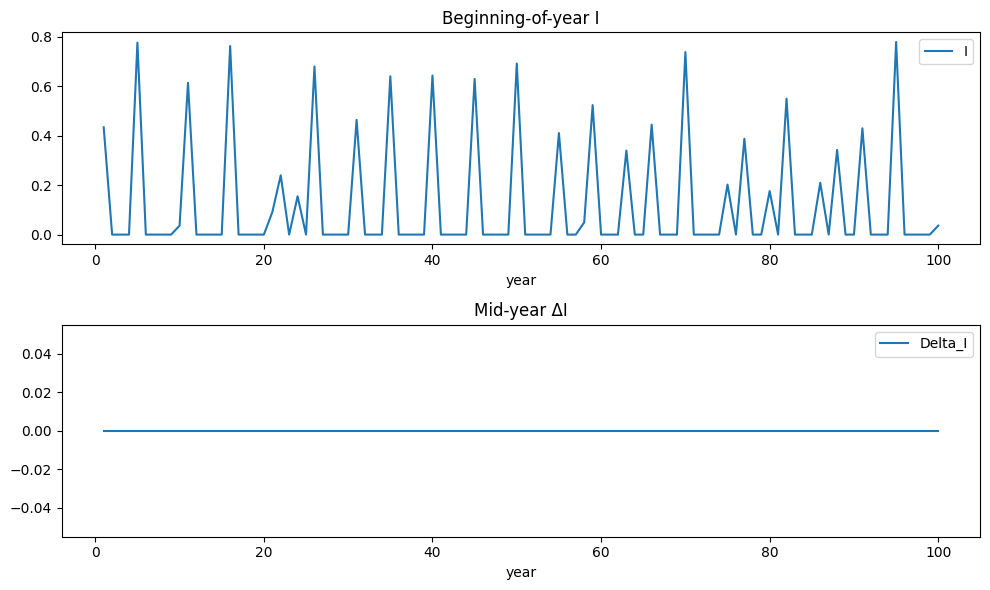

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
firm = panel_2.query('firm_id == 1')
firm.plot(x='year', y='I', ax=axes[0], title='Beginning-of-year I')
firm.plot(x='year', y='Delta_I', ax=axes[1], title='Mid-year ΔI')
plt.tight_layout()

<Axes: xlabel='year'>

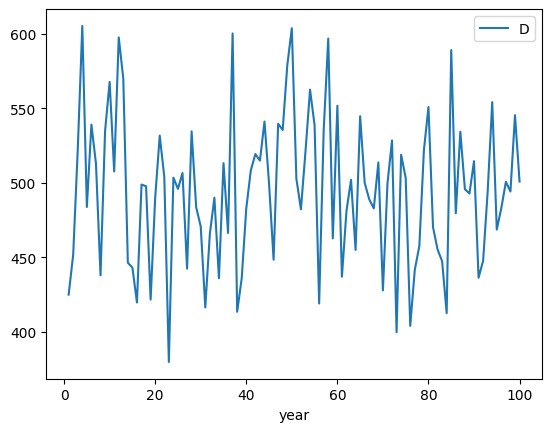

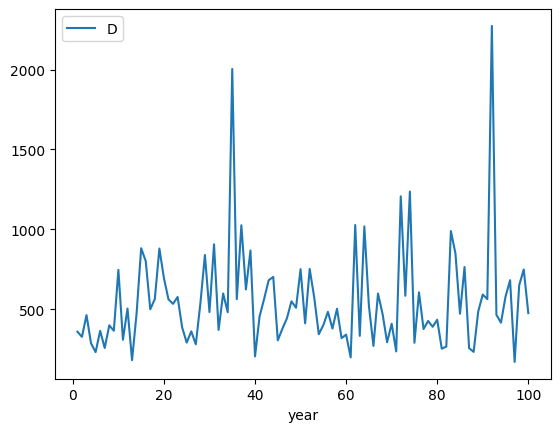

In [42]:
panel_1.query('firm_id == 1').plot(x = "year",y = "D")
panel_2.query('firm_id == 1').plot(x = "year",y = "D")

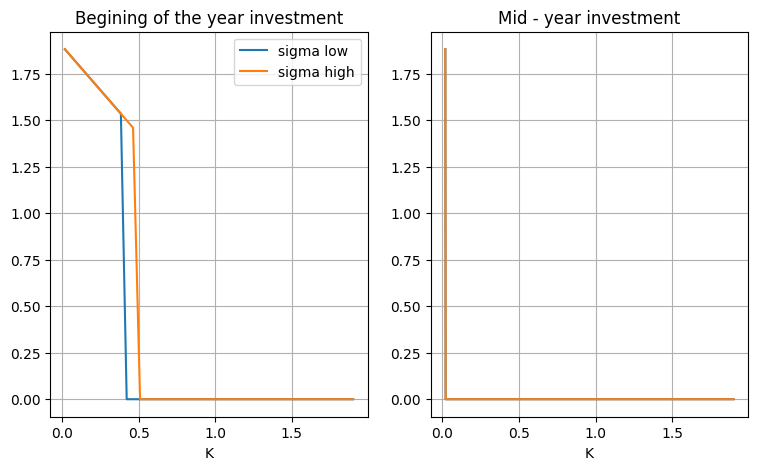

In [78]:
K_grid = np.load(os.path.join(folder_path,"grid_K.npy"))

fig,axs = plt.subplots(1,2,figsize = (9,5))


I_policy_s11 = np.load(os.path.join(folder_path,f"I_policy_s{test}1.npy"))
axs[0].plot(K_grid,I_policy_s11[:,0,0],label = "sigma low")

I_policy_s12 = np.load(os.path.join(folder_path,f"I_policy_s{test}2.npy"))
axs[0].plot(K_grid,I_policy_s12[:,0,0],label ="sigma high")
axs[0].grid()

Delta_I_policy_s11 = np.load(os.path.join(folder_path,f"Delta_I_policy_s{test}1.npy"))
axs[1].plot(K_grid,Delta_I_policy_s11[:,0,0])

Delta_I_policy_s12 = np.load(os.path.join(folder_path,f"Delta_I_policy_s{test}2.npy"))
axs[1].plot(K_grid,Delta_I_policy_s12[:,0,0])
axs[1].grid()

axs[0].set_title("Begining of the year investment")
axs[1].set_title("Mid - year investment")
axs[0].set_xlabel('K')
axs[1].set_xlabel('K')
axs[0].legend()


In [63]:
panel_1.query('firm_id == 1').head()

,firm_id,year,K,D,D_half,sigma,sigma_half,log_D,log_D_half,log_sigma,log_sigma_half,I,Delta_I,I_total,I_rate,profit
0,1,1,1.000000,311.952011,338.365051,0.099999,0.099998,5.742849,5.824125,-2.302597,-2.302600,0.803941,0.0,0.803941,0.803941,0.434433
1,1,2,1.662685,317.944339,382.086059,0.099999,0.100000,5.761876,5.945646,-2.302600,-2.302581,0.000000,0.0,0.000000,0.000000,0.488085
2,1,3,1.496417,409.951887,396.722570,0.100001,0.100000,6.016040,5.983237,-2.302577,-2.302581,0.000000,0.0,0.000000,0.000000,0.549032
3,1,4,1.346775,491.366529,534.625481,0.099998,0.099999,6.197190,6.281566,-2.302600,-2.302597,0.000000,0.0,0.000000,0.000000,0.674728
4,1,5,1.212097,513.831242,513.902587,0.100001,0.099999,6.241895,6.242034,-2.302571,-2.302598,0.000000,0.0,0.000000,0.000000,0.668794


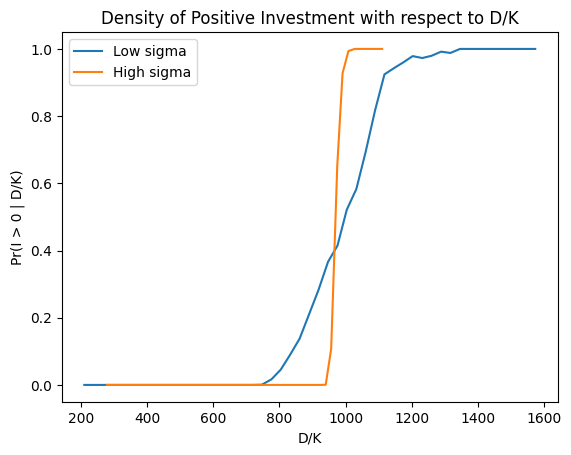

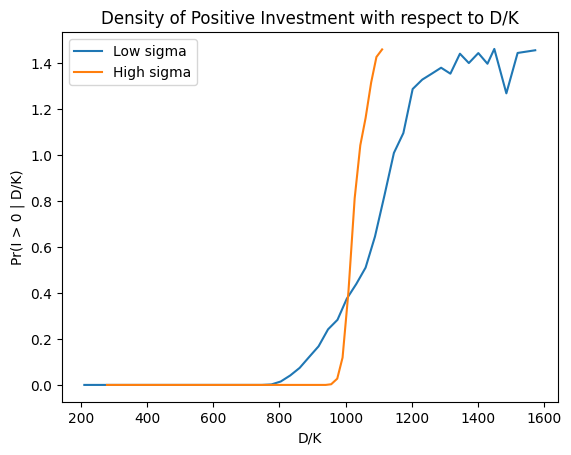

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def investment_stat_density(panel, label, stat="probability", bins=50):
    """
    Plot a conditional statistic of investment as a function of D/K.

    Parameters
    ----------
    panel : dict-like or DataFrame
        Must contain columns "D", "K", and "I_total".
    label : str
        Label used in the plot legend.
    stat : str
        "probability"  -> Pr(I_total > 0 | D/K)
        "expectation"  -> E[I_total | D/K]
    bins : int
        Number of bins for D/K.
    """

    ratio = panel["D"] / panel["K"]
    investment = panel["I_total"]

    # statistic selector
    if stat == "probability":
        y = (investment > 0).astype(float)
        ylabel = "Pr(I > 0 | D/K)"
    elif stat == "expectation":
        y = investment
        ylabel = "E[I | D/K]"
    else:
        raise ValueError("stat must be 'probability' or 'expectation'")

    # bins
    grid = np.linspace(ratio.min(), ratio.max(), bins)
    bin_ids = np.digitize(ratio, grid)

    bin_centers = []
    stat_values = []

    for b in range(1, len(grid)):
        mask = bin_ids == b
        if mask.sum() > 0:
            bin_centers.append(ratio[mask].mean())
            stat_values.append(y[mask].mean())

    plt.plot(bin_centers, stat_values, label=label)

    return ylabel


# Plot both panels
plt.figure()
investment_stat_density(panel_1, "Low sigma",stat = "probability")
investment_stat_density(panel_2, "High sigma",stat = "probability")

plt.xlabel("D/K")
plt.ylabel("Pr(I > 0 | D/K)")
plt.title("Density of Positive Investment with respect to D/K")
plt.legend()
plt.show()

plt.figure()
investment_stat_density(panel_1, "Low sigma",stat = "expectation")
investment_stat_density(panel_2, "High sigma",stat = "expectation")

plt.xlabel("D/K")
plt.ylabel("Pr(I > 0 | D/K)")
plt.title("Density of Positive Investment with respect to D/K")
plt.legend()
plt.show()

<Axes: xlabel='year'>

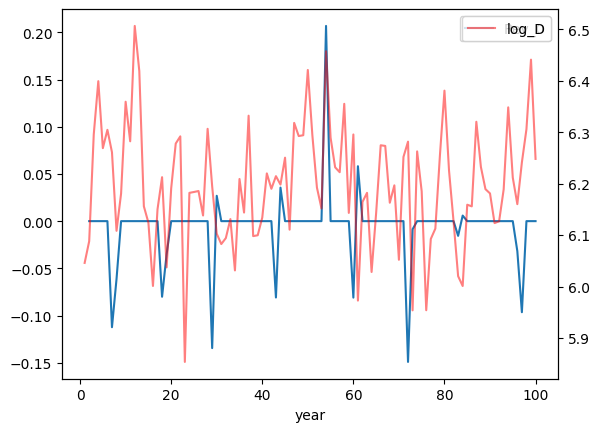

In [37]:
fig,ax = plt.subplots()

panel_1['Rev_0'] = panel_1['E_beginning']-panel_1['E_last_semester']
panel_1.query("firm_id == 1").plot(x = "year",y = "Rev_0",ax = ax)
ax = ax.twinx()
panel_1.query("firm_id == 1").plot(x = "year",y = "log_D",ax = ax,color = "red",alpha = 0.5)


In [41]:
pf.feols("E_beginning ~I_total | C(firm_id) ", data = panel_1).summary()

###

Estimation:  OLS
Dep. var.: E_beginning, Fixed effects: C(firm_id)
Inference:  iid
Observations:  100000

| Coefficient   |   Estimate |   Std. Error |                 t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|------------------------:|-----------:|-------:|--------:|
| I_total       |      1.000 |        0.000 | 2070001992493143040.000 |      0.000 |  1.000 |   1.000 |
---
RMSE: 0.0 R2: 1.0 R2 Within: 1.0 


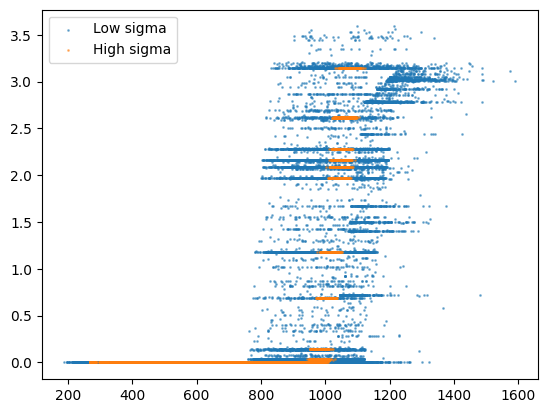

In [15]:
plt.scatter(panel_1.D/panel_1.K,panel_1.I_rate,alpha = 0.5,s = 1,label = "Low sigma")
plt.scatter(panel_2.D/panel_2.K,panel_2.I_rate,alpha = 0.5,s = 1,label = "High sigma")
plt.legend()

In [1]:
pf

NameError: name 'pf' is not defined

In [38]:
pf.feols("I_total ~sigma + K ", data = panel_1).summary()
pf.feols("I_total ~sigma + K ", data = panel_2).summary()

###

Estimation:  OLS
Dep. var.: I_total, Fixed effects: 0
Inference:  iid
Observations:  100000

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |     2.5% |    97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|---------:|---------:|
| Intercept     |    -41.324 |       71.640 |    -0.577 |      0.564 | -181.737 |   99.089 |
| sigma         |    425.736 |      716.396 |     0.594 |      0.552 | -978.390 | 1829.863 |
| K             |     -0.810 |        0.003 |  -247.805 |      0.000 |   -0.817 |   -0.804 |
---
RMSE: 0.227 R2: 0.38 
###

Estimation:  OLS
Dep. var.: I_total, Fixed effects: 0
Inference:  iid
Observations:  100000

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |     2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|---------:|--------:|
| Intercept     |     -6.838 |       57.882 |    -0.118 |      0.906 | -120.287 | 106.610 |
| sigma         |     15.901 |      1

## Test 2

- No uncertainty
- Different fixed cost between begin and mid-year

Same fixed cost : Should invest in the semi period. 
Increasing the fixed cost should push the firm to invest in the other semi period. 

In [95]:
test = 3

<Axes: xlabel='year'>

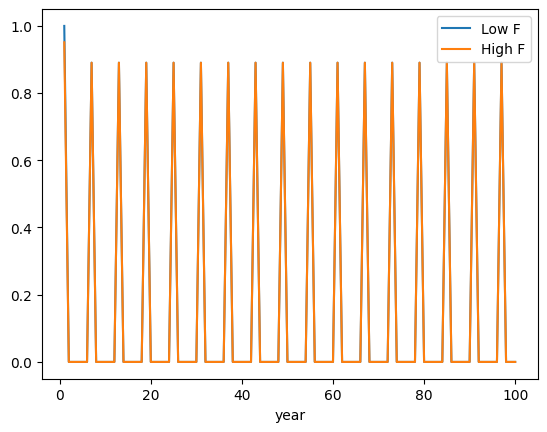

In [96]:
panel_1 = pd.read_parquet(os.path.join(folder_path,f"panel_data_s{test}1.parquet"))
panel_2 = pd.read_parquet(os.path.join(folder_path,f"panel_data_s{test}2.parquet"))

fix, ax = plt.subplots()
panel_1.query('firm_id == 1').plot(x = "year",y = 'I_total',ax =ax,label = "Low F")
panel_2.query('firm_id == 1').plot(x = "year",y = 'I',ax =ax,label = "High F")

Text(0.5, 0, 'K')

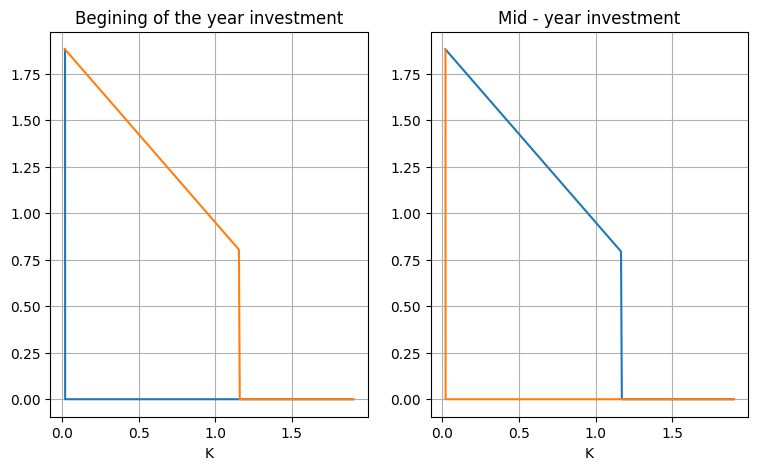

In [97]:
K_grid = np.load(os.path.join(folder_path,"grid_K.npy"))

fig,axs = plt.subplots(1,2,figsize = (9,5))


I_policy_s1 = np.load(os.path.join(folder_path,f"I_policy_s{test}1.npy"))
axs[0].plot(K_grid,I_policy_s1[:,0,0])

I_policy_s2 = np.load(os.path.join(folder_path,f"I_policy_s{test}2.npy"))
axs[0].plot(K_grid,I_policy_s2[:,0,0])
axs[0].grid()

Delta_I_policy_s1 = np.load(os.path.join(folder_path,f"Delta_I_policy_s{test}1.npy"))
axs[1].plot(K_grid,Delta_I_policy_s1[:,0,0])

Delta_I_policy_s2 = np.load(os.path.join(folder_path,f"Delta_I_policy_s{test}2.npy"))
axs[1].plot(K_grid,Delta_I_policy_s2[:,0,0])
axs[1].grid()

axs[0].set_title("Begining of the year investment")
axs[1].set_title("Mid - year investment")
axs[0].set_xlabel('K')
axs[1].set_xlabel('K')